<a href="https://colab.research.google.com/github/gianni04/projet-google-colab/blob/main/EUR_US_Yield_Curveipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELLULE 1 : Installation des dépendances
!pip install sdmx1 scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 4.9 MB/s eta 0:00:00


In [ ]:
# CELLULE 2 : Imports et configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import sdmx
import logging
from datetime import date
from pandas.tseries.offsets import BDay
from dateutil.relativedelta import relativedelta
from scipy.interpolate import interp1d

# Configuration du logger pour le débogage
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

In [ ]:
# CELLULE 3 : Constantes et fonctions utiles
TODAY = date.today()
MONTH_MATURITIES = range(3, 12)
YEAR_MATURITIES = range(1, 31)

# Formatage des maturités pour l'API BCE
MATURITIES_API = [(f'SR_{m}M', f'{m}M') for m in MONTH_MATURITIES] + \
                 [(f'SR_{y}Y', f'{y}Y') for y in YEAR_MATURITIES]
KEYS_API, LABELS_API = zip(*MATURITIES_API)

# Fonction de base de calcul (Actual/Actual)
def is_leap_year(idx):
    return (idx.year % 4 == 0) & ((idx.year % 100 != 0) | (idx.year % 400 == 0))

In [ ]:
# CELLULE 4 : Classe MarketDataFetcher (POO)
class MarketDataFetcher:
    """Gère les requêtes vers l'API SDMX de la BCE avec robustesse."""
    def __init__(self):
        self.client = sdmx.Client('ECB')

    def fetch_spot_rates(self):
        try:
            logging.info("Récupération de la courbe Spot AAA BCE...")
            data_msg = self.client.data(
                'YC',
                key='B.U2.EUR.4F.G_N_A.SV_C_YM.' + '+'.join(KEYS_API),
                params={'startPeriod': (TODAY - BDay(5)).date()}
            )
            df = sdmx.to_pandas(data_msg.data[0]) / 100.

            if isinstance(df, pd.DataFrame):
                df = df.loc['B', 'U2', 'EUR', '4F', 'G_N_A', 'SV_C_YM'].unstack(level=-2)
            else:
                df = df.loc[slice(None), 'B', 'U2', 'EUR', '4F', 'G_N_A', 'SV_C_YM'].unstack('DATA_TYPE_FM')

            df.index = pd.DatetimeIndex(df.index)
            return df.loc[:, KEYS_API].set_axis(LABELS_API, axis=1)
        except Exception as e:
            logging.error(f"Échec de récupération des taux spot : {e}")
            return None

    def fetch_short_end(self, start_date):
        try:
            logging.info("Récupération DFR et €STR...")
            # DFR
            msg_dfr = self.client.data('FM', key='B.U2.EUR.4F.KR.DFR.LEV', params={'startPeriod': start_date})
            dfr = sdmx.to_pandas(msg_dfr.data[0]) / 100.
            dfr = dfr.xs(('B', 'U2', 'EUR', '4F', 'KR', 'DFR', 'LEV'), level=[1,2,3,4,5,6,7]) if not isinstance(dfr, pd.DataFrame) else dfr
            dfr.index = pd.DatetimeIndex(dfr.index)

            # €STR
            msg_estr = self.client.data('EST', key='B.EU000A2X2A25.WT', params={'startPeriod': start_date})
            estr = sdmx.to_pandas(msg_estr.data[0]) / 100.
            estr = estr.xs(('B', 'EU000A2X2A25', 'WT'), level=[1,2,3]) if not isinstance(estr, pd.DataFrame) else estr
            estr.index = pd.DatetimeIndex(estr.index)

            return dfr, estr
        except Exception as e:
            logging.error(f"Échec de récupération du bout court : {e}")
            return None, None

In [ ]:
# CELLULE 5 : Classe YieldCurve (Interpolation Log-Linéaire)
class YieldCurve:
    """Construit la courbe de taux et gère l'interpolation propre au pricing."""
    def __init__(self, tenors_years, rates_continuous):
        self.tenors = np.array(tenors_years)
        self.rates = np.array(rates_continuous)

        # Le standard de marché : Interpolation linéaire sur le log des facteurs d'actualisation
        # P(0,t) = exp(-r * t) -> ln(P) = -r * t
        self.discount_factors = np.exp(-self.rates * self.tenors)
        self.log_df = np.log(self.discount_factors)

        # Extrapolation flat en dehors des bornes
        self.interp_log_df = interp1d(self.tenors, self.log_df, kind='linear', fill_value="extrapolate")

    def get_discount_factor(self, t):
        """Retourne le ZC discount factor pour une maturité t."""
        return np.exp(self.interp_log_df(t))

    def get_zero_rate(self, t):
        """Retourne le taux zéro-coupon continu pour une maturité t."""
        if t == 0:
            return self.rates[0]
        df = self.get_discount_factor(t)
        return -np.log(df) / t

    def get_forward_rate(self, t1, t2):
        """Calcule le taux forward continu entre t1 et t2."""
        df1 = self.get_discount_factor(t1)
        df2 = self.get_discount_factor(t2)
        return (1 / (t2 - t1)) * np.log(df1 / df2)

In [ ]:
# CELLULE 6 : Pipeline d'extraction et construction
fetcher = MarketDataFetcher()

# 1. Extraction
spot_rates = fetcher.fetch_spot_rates()
start_date_short = TODAY - relativedelta(years=1)
dfr, estr = fetcher.fetch_short_end(start_date_short)

# 2. Nettoyage et fusion du bout court (Min(€STR, DFR))
dfr = dfr.reindex(spot_rates.index.union(dfr.index)).ffill().dropna()
estr = estr.reindex(dfr.index).dropna()
overnight_rate = pd.concat([estr, dfr.loc[estr.index]], axis=1).min(axis=1)

# 3. Conversions des conventions monétaires
leap_mask = is_leap_year(overnight_rate.index)
overnight_rate[leap_mask] *= 366. / 360
overnight_rate[~leap_mask] *= 365. / 360
overnight_rate = np.log(1 + overnight_rate) # Passage en continu

# 4. Préparation des vecteurs pour l'interpolation
last_date = spot_rates.index[-1]
overnight_val = float(overnight_rate.loc[overnight_rate.index <= last_date].iloc[-1])
spot_vals = spot_rates.iloc[-1].values.tolist()

all_rates = [overnight_val] + spot_vals
tenors_in_years = [0.0] + [m/12 for m in MONTH_MATURITIES] + [float(y) for y in YEAR_MATURITIES]

# 5. Instanciation de la courbe
curve = YieldCurve(tenors_in_years, all_rates)
logging.info(f"Courbe construite avec succès pour la date : {last_date.date()}")

/tmp/ipykernel_2428/2022475974.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  overnight_val = float(overnight_rate.loc[overnight_rate.index <= last_date][-1])


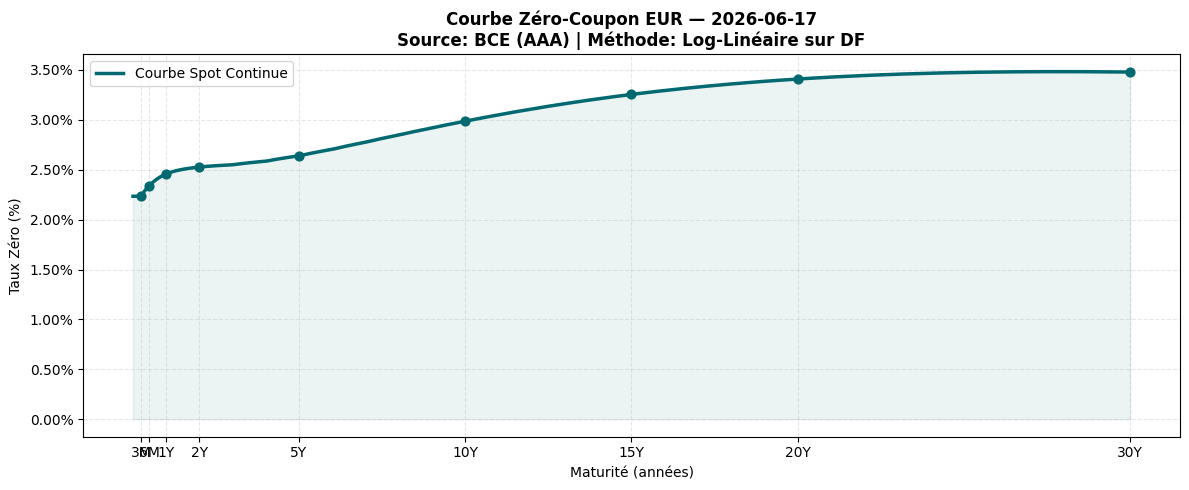

In [ ]:
# CELLULE 7 : Affichage de la courbe Zero-Coupon
t_fine = np.linspace(0.01, 30, 500)
r_fine = [curve.get_zero_rate(t) * 100 for t in t_fine]

x_vals = [0.25, 0.5, 1, 2, 5, 10, 15, 20, 30]
x_labels = ['3M', '6M', '1Y', '2Y', '5Y', '10Y', '15Y', '20Y', '30Y']
r_nodes = [curve.get_zero_rate(t) * 100 for t in x_vals]

plt.figure(figsize=(12, 5))
plt.plot(t_fine, r_fine, color='#01696f', linewidth=2.5, label="Courbe Spot Continue")
plt.scatter(x_vals, r_nodes, color='#01696f', zorder=5, s=40)
plt.fill_between(t_fine, r_fine, alpha=0.08, color='#01696f')

plt.xticks(x_vals, x_labels)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
plt.grid(True, alpha=0.3, linestyle='--')
plt.title(f'Courbe Zéro-Coupon EUR — {last_date.date()}\nSource: BCE (AAA) | Méthode: Log-Linéaire sur DF', fontweight='bold')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux Zéro (%)')
plt.legend()
plt.tight_layout()
plt.show()

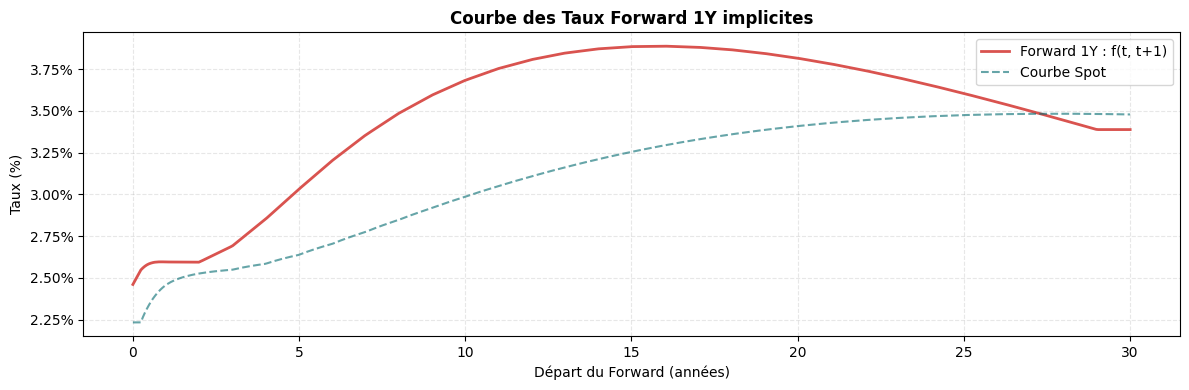

In [ ]:
# CELLULE 8 : Preuve de robustesse (Courbe Forward 1Y)
fwds_1y = [curve.get_forward_rate(t, t+1) * 100 for t in t_fine]

plt.figure(figsize=(12, 4))
plt.plot(t_fine, fwds_1y, color='#d9534f', linewidth=2, label="Forward 1Y : f(t, t+1)")
plt.plot(t_fine, r_fine, color='#01696f', linewidth=1.5, linestyle='--', alpha=0.6, label="Courbe Spot")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
plt.grid(True, alpha=0.3, linestyle='--')
plt.title("Courbe des Taux Forward 1Y implicites", fontweight='bold')
plt.xlabel("Départ du Forward (années)")
plt.ylabel("Taux (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# CELLULE 9 : Application - Pricing d'un Swap (IRS)
def calculate_par_swap_rate(curve, maturity_years, freq_months=6):
    """
    Calcule le taux de swap au pair (Par Swap Rate) pour une maturité donnée.
    Hypothèse simplifiée : Jambe fixe vs Jambe flottante sur la même courbe (OIS discount).
    """
    dt = freq_months / 12
    payment_times = np.arange(dt, maturity_years + dt, dt)

    # Somme des facteurs d'actualisation (PV01 / Annuity)
    annuity = sum([curve.get_discount_factor(t) * dt for t in payment_times])

    # Taux de swap = (1 - P(0,T)) / Annuity
    df_T = curve.get_discount_factor(maturity_years)
    par_rate = (1 - df_T) / annuity
    return par_rate

print("--- GRILLE DE TAUX SWAP AU PAIR (Simplifiée) ---")
for mat in [2, 5, 10, 30]:
    rate = calculate_par_swap_rate(curve, maturity_years=mat)
    print(f"Swap {mat}Y : {rate * 100:.4f} %")

--- GRILLE DE TAUX SWAP AU PAIR (Simplifiée) ---
Swap 2Y : 2.5415 %
Swap 5Y : 2.6509 %
Swap 10Y : 2.9748 %
Swap 30Y : 3.4133 %


In [ ]:
# CELLULE 1 : Installation des dépendances (US)
!pip install pandas-datareader scipy -q

In [ ]:
# CELLULE 2 : Imports et configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas_datareader.data as web
import logging
import datetime
from scipy.interpolate import interp1d

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

In [ ]:
# CELLULE 3 : Constantes et Tickers FRED
TODAY = datetime.date.today()
START_DATE = TODAY - datetime.timedelta(days=15) # Marge pour jours fériés

# Tickers de la Fed (FRED)
OIS_TICKER = 'SOFR' # Secured Overnight Financing Rate
TREASURY_TICKERS = {
    '1M': 'DGS1MO', '3M': 'DGS3MO', '6M': 'DGS6MO',
    '1Y': 'DGS1', '2Y': 'DGS2', '3Y': 'DGS3',
    '5Y': 'DGS5', '7Y': 'DGS7', '10Y': 'DGS10',
    '20Y': 'DGS20', '30Y': 'DGS30'
}

# Maturités en années pour l'axe X
TENORS_YEARS = [0.0, 1/12, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0]

In [ ]:
# CELLULE 4 : Classe USMarketDataFetcher
class USMarketDataFetcher:
    """Récupère les taux SOFR et Treasuries depuis la Fed (FRED)."""

    @staticmethod
    def fetch_data(start, end):
        tickers = [OIS_TICKER] + list(TREASURY_TICKERS.values())
        try:
            logging.info("Connexion à FRED (Federal Reserve) via pandas_datareader...")
            # Récupération des données
            df = web.DataReader(tickers, 'fred', start, end)

            # Nettoyage : Les jours fériés US créent des NaN, on forward fill
            df = df.ffill().dropna()

            # Conversion en pourcentages mathématiques
            df = df / 100.0
            return df
        except Exception as e:
            logging.error(f"Erreur de récupération FRED : {e}")
            return None

In [ ]:
# CELLULE 5 : Classe YieldCurve (Interpolation Log-Linéaire)
class YieldCurve:
    """Construit la courbe de taux et gère l'interpolation log-linéaire (Standard Marché)."""
    def __init__(self, tenors_years, rates_continuous):
        self.tenors = np.array(tenors_years)
        self.rates = np.array(rates_continuous)

        # ln(P) = -r * t
        self.discount_factors = np.exp(-self.rates * self.tenors)
        self.log_df = np.log(self.discount_factors)

        # Extrapolation flat
        self.interp_log_df = interp1d(self.tenors, self.log_df, kind='linear', fill_value="extrapolate")

    def get_discount_factor(self, t):
        return np.exp(self.interp_log_df(t))

    def get_zero_rate(self, t):
        if t == 0:
            return self.rates[0]
        df = self.get_discount_factor(t)
        return -np.log(df) / t

    def get_forward_rate(self, t1, t2):
        df1 = self.get_discount_factor(t1)
        df2 = self.get_discount_factor(t2)
        return (1 / (t2 - t1)) * np.log(df1 / df2)

In [ ]:
# CELLULE 6 : Construction de la courbe US
# 1. Extraction
df_market = USMarketDataFetcher.fetch_data(START_DATE, TODAY)
latest_date = df_market.index[-1]
market_rates = df_market.iloc[-1]

# 2. Conversions (Le point Quant critique)
# - SOFR & T-Bills (<= 1Y) : Composition simple (Actual/360) convertie en continu
# - T-Notes/Bonds (> 1Y) : Composition semi-annuelle convertie en continu
continuous_rates = []

# Traitement du SOFR (Overnight)
r_sofr = market_rates[OIS_TICKER]
continuous_rates.append(np.log(1 + r_sofr * (365/360)))

# Traitement des Treasuries
for label, ticker in TREASURY_TICKERS.items():
    r = market_rates[ticker]
    if label in ['1M', '3M', '6M', '1Y']:
        # T-Bills (Simple interest)
        r_cont = np.log(1 + r)
    else:
        # T-Notes/Bonds (Semi-annual bond equivalent yield -> Continuous)
        r_cont = 2 * np.log(1 + r / 2)
    continuous_rates.append(r_cont)

# 3. Instanciation
curve_usd = YieldCurve(TENORS_YEARS, continuous_rates)
logging.info(f"Courbe USD construite avec succès pour la date : {latest_date.date()}")

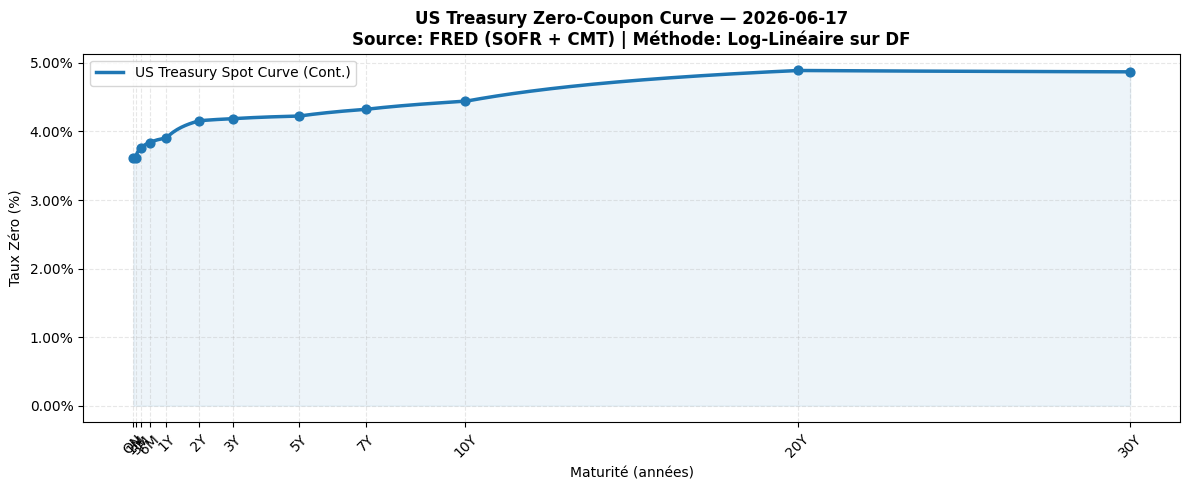

In [ ]:
# CELLULE 7 : Affichage Courbe Spot USD
t_fine = np.linspace(0.01, 30, 500)
r_fine = [curve_usd.get_zero_rate(t) * 100 for t in t_fine]

x_labels = ['ON', '1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
r_nodes = [curve_usd.get_zero_rate(t) * 100 for t in TENORS_YEARS]

plt.figure(figsize=(12, 5))
plt.plot(t_fine, r_fine, color='#1f77b4', linewidth=2.5, label="US Treasury Spot Curve (Cont.)")
plt.scatter(TENORS_YEARS, r_nodes, color='#1f77b4', zorder=5, s=40)
plt.fill_between(t_fine, r_fine, alpha=0.08, color='#1f77b4')

plt.xticks(TENORS_YEARS, x_labels, rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
plt.grid(True, alpha=0.3, linestyle='--')
plt.title(f'US Treasury Zero-Coupon Curve — {latest_date.date()}\nSource: FRED (SOFR + CMT) | Méthode: Log-Linéaire sur DF', fontweight='bold')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux Zéro (%)')
plt.legend()
plt.tight_layout()
plt.show()

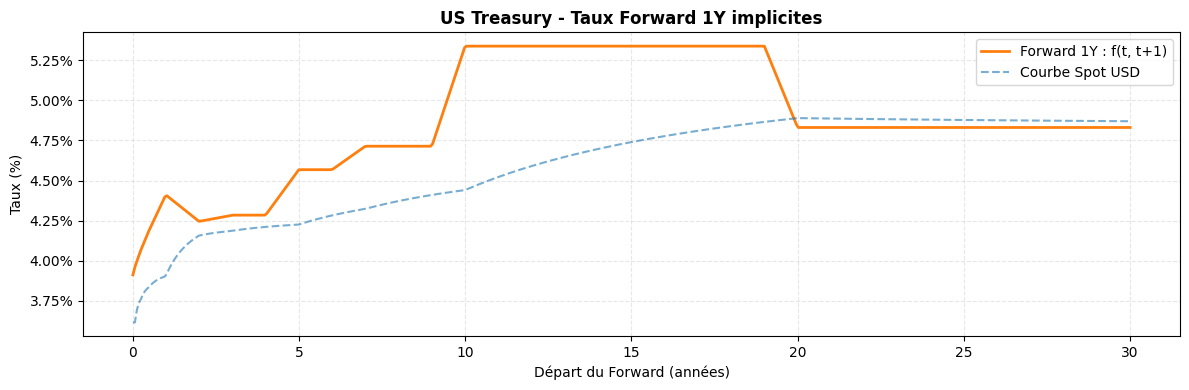

In [ ]:

# CELLULE 8 : Courbe des Forwards 1Y (USD)

fwds_1y = [curve_usd.get_forward_rate(t, t+1) * 100 for t in t_fine]

plt.figure(figsize=(12, 4))
plt.plot(t_fine, fwds_1y, color='#ff7f0e', linewidth=2, label="Forward 1Y : f(t, t+1)")
plt.plot(t_fine, r_fine, color='#1f77b4', linewidth=1.5, linestyle='--', alpha=0.6, label="Courbe Spot USD")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
plt.grid(True, alpha=0.3, linestyle='--')
plt.title("US Treasury - Taux Forward 1Y implicites", fontweight='bold')
plt.xlabel("Départ du Forward (années)")
plt.ylabel("Taux (%)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

# CELLULE 9 : Application - Analyse des Taux US
def calculate_par_swap_rate(curve, maturity_years, freq_months=6):
    """Calcule le taux de swap au pair USD."""
    dt = freq_months / 12
    payment_times = np.arange(dt, maturity_years + dt, dt)
    annuity = sum([curve.get_discount_factor(t) * dt for t in payment_times])
    df_T = curve.get_discount_factor(maturity_years)
    return (1 - df_T) / annuity

print("--- GRILLE DE TAUX SWAP AU PAIR USD ---")
print(f"Date de marché : {latest_date.date()}")
print("-" * 35)
for mat in [2, 5, 10, 30]:
    rate = calculate_par_swap_rate(curve_usd, maturity_years=mat)
    print(f"Swap USD {mat}Y : {rate * 100:>7.4f} %")

# Calcul de pente de courbe (Steepness) très suivi par les traders :
spread_2_10 = (curve_usd.get_zero_rate(10) - curve_usd.get_zero_rate(2)) * 10000
print("-" * 35)
print(f"Spread 2s10s (Pente 10Y - 2Y) : {spread_2_10:.1f} bps")
if spread_2_10 < 0:
    print("-> La courbe US est actuellement INVERSÉE (Signe classique de risque de récession).")
else:
    print("-> La courbe US est PENTUE (Normale).")

--- GRILLE DE TAUX SWAP AU PAIR USD ---
Date de marché : 2026-06-17
-----------------------------------
Swap USD 2Y :  4.1943 %
Swap USD 5Y :  4.2642 %
Swap USD 10Y :  4.4606 %
Swap USD 30Y :  4.8336 %
-----------------------------------
Spread 2s10s (Pente 10Y - 2Y) : 28.4 bps
-> La courbe US est PENTUE (Normale).
